# Spatial Probability of Aftershocks Given an Identified Mainshock — Southeast Asia

**Data cleaning + 7 source-zone classification + EDA**

This notebook reproduces `scripts/01_clean_data.py`, `scripts/02_source_zones.py`,
and `scripts/03_eda.py` as one interactive workflow. Run cells top to bottom.

**Requirements:** run this notebook from the **repository root** (so the relative
paths `data/raw/...`, `data/processed/...`, `figures/...`, `reports/...` resolve
correctly), with `pandas`, `numpy`, `matplotlib`, `scipy` installed:

```bash
pip install pandas numpy matplotlib scipy
```

See `reports/02_eda_report.md` for the full written chapter (methodology,
findings, data-quality caveats, and next steps for the modeling stage).


In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure we're at the repo root (folder containing data/, scripts/, reports/)
assert os.path.isdir("data/raw"), (
    "Run this notebook from the repository root - 'data/raw' not found in "
    f"the current working directory ({os.getcwd()})."
)

os.makedirs("data/processed", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("figures", exist_ok=True)


## Step 1 — Data cleaning and standardization

Combines two raw earthquake catalogs into a single, standardized catalog:
- **TMD** local earthquake catalog (Thai Meteorological Department), 2007-2026
  — note: the source file is **Windows-874 / TIS-620** encoded, not UTF-8.
- **USGS** regional catalog for Southeast Asia, 2012-2026.

Both are mapped to a common schema (`event_id, time_utc, lat, lon, depth_km,
mag, mag_type, network, place`), then deduplicated: larger regional events are
often reported by both networks, so any TMD event within 60s / 50km of a USGS
event is treated as the same earthquake and dropped in favor of the USGS
record (kept as network-of-record for shared events).


In [2]:
RAW_TMD = "data/raw/tmd_local_earthquake.csv"
RAW_USGS = "data/raw/usgs_combined_2012_2026.csv"


def load_tmd():
    df = pd.read_csv(RAW_TMD, encoding="cp874")
    df.columns = [c.strip() for c in df.columns]

    out = pd.DataFrame()
    out["event_id"] = "TMD_" + df["REF. ID"].astype(str).str.strip()
    out["time_utc"] = pd.to_datetime(df["DATE-TIME UTC"], errors="coerce")
    out["lat"] = pd.to_numeric(df["LAT."], errors="coerce")
    out["lon"] = pd.to_numeric(df["LONG."], errors="coerce")
    out["depth_km"] = pd.to_numeric(df["DEPTH."], errors="coerce")
    out["mag"] = pd.to_numeric(df["MAG."], errors="coerce")
    out["mag_type"] = "ML(TMD)"
    out["network"] = "TMD"
    # Source has two REGION columns (Thai description, sometimes English);
    # pandas renames the second to "REGION..1". Prefer Thai text, fall back to English.
    region_th = df["REGION."].astype(str).str.strip()
    region_en = df["REGION..1"].astype(str).str.strip() if "REGION..1" in df.columns else ""
    out["place"] = region_th.where(region_th.ne("") & region_th.ne("nan"), region_en)

    out = out.dropna(subset=["time_utc", "lat", "lon", "mag"])
    out = out[(out["lat"].between(-90, 90)) & (out["lon"].between(-180, 180))]
    out = out[out["mag"] > 0]
    return out


def load_usgs():
    df = pd.read_csv(RAW_USGS)
    df = df[df["type"] == "earthquake"]

    out = pd.DataFrame()
    out["event_id"] = "USGS_" + df["id"].astype(str)
    out["time_utc"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_localize(None)
    out["lat"] = pd.to_numeric(df["latitude"], errors="coerce")
    out["lon"] = pd.to_numeric(df["longitude"], errors="coerce")
    out["depth_km"] = pd.to_numeric(df["depth"], errors="coerce")
    out["mag"] = pd.to_numeric(df["mag"], errors="coerce")
    out["mag_type"] = df["magType"].astype(str)
    out["network"] = "USGS/" + df["net"].astype(str).str.upper()
    out["place"] = df["place"].astype(str)

    out = out.dropna(subset=["time_utc", "lat", "lon", "mag"])
    out = out[(out["lat"].between(-90, 90)) & (out["lon"].between(-180, 180))]
    out = out[out["mag"] > 0]
    return out


tmd = load_tmd()
usgs = load_usgs()
print(f"TMD:  {len(tmd)} events kept")
print(f"USGS: {len(usgs)} events kept")


TMD:  16656 events kept
USGS: 47151 events kept


In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


def dedupe(tmd, usgs):
    """Flag TMD events within 60s / 50km of a USGS event as duplicates and drop them."""
    tmd = tmd.sort_values("time_utc").reset_index(drop=True)
    usgs_sorted = usgs.sort_values("time_utc").reset_index(drop=True)
    u_times = usgs_sorted["time_utc"].values
    u_lat = usgs_sorted["lat"].values
    u_lon = usgs_sorted["lon"].values

    window = np.timedelta64(60, "s")
    is_dup = np.zeros(len(tmd), dtype=bool)
    lo = 0
    for i, t in enumerate(tmd["time_utc"].values):
        while lo < len(u_times) and u_times[lo] < t - window:
            lo += 1
        j = lo
        while j < len(u_times) and u_times[j] <= t + window:
            d = haversine_km(tmd["lat"].iloc[i], tmd["lon"].iloc[i], u_lat[j], u_lon[j])
            if d <= 50:
                is_dup[i] = True
                break
            j += 1
    return tmd.loc[~is_dup].reset_index(drop=True), int(is_dup.sum())


tmd_unique, n_dup = dedupe(tmd, usgs)
print(f"Dropped {n_dup} TMD events as duplicates of a USGS event.")

catalog = pd.concat([tmd_unique, usgs], ignore_index=True).sort_values("time_utc").reset_index(drop=True)
n_before = len(catalog)
catalog = catalog.drop_duplicates(subset=["network", "time_utc", "lat", "lon", "mag"])
print(f"Removed {n_before - len(catalog)} exact duplicate rows within the same network.")

catalog.to_csv("data/processed/catalog_clean.csv", index=False)
print(f"\nFinal combined catalog: {len(catalog)} events -> data/processed/catalog_clean.csv")
print(f"Time range: {catalog['time_utc'].min()} to {catalog['time_utc'].max()}")
print(f"Magnitude range: {catalog['mag'].min():.1f} to {catalog['mag'].max():.1f}")
print(f"\nEvents by network:\n{catalog['network'].value_counts().to_string()}")
catalog.head()


Dropped 1270 TMD events as duplicates of a USGS event.
Removed 31 exact duplicate rows within the same network.



Final combined catalog: 62506 events -> data/processed/catalog_clean.csv
Time range: 2007-01-04 08:38:00 to 2026-09-11 00:53:48.954000
Magnitude range: 0.6 to 8.6

Events by network:
network
USGS/US          47131
TMD              15374
USGS/OFFICIAL        1


,event_id,time_utc,lat,lon,depth_km,mag,mag_type,network,place
0,TMD_TM0001,2007-01-04 08:38:00,18.9,99.00,0.0,2.4,ML(TMD),TMD,อ.แม่ริม จ.เชียงใหม่
1,TMD_TM0002,2007-01-06 02:23:00,18.9,99.00,0.0,3.1,ML(TMD),TMD,อ.แม่ริม จ.เชียงใหม่
2,TMD_TM0003,2007-04-22 06:18:00,19.4,99.36,0.0,4.5,ML(TMD),TMD,อ.เวียงป่าเป้า จ.เชียงราย
3,TMD_TM0004,2007-04-23 14:18:00,19.6,99.20,0.0,4.0,ML(TMD),TMD,อ.พร้าว จ.เชียงใหม่
4,TMD_TM0005,2007-05-16 10:04:00,21.0,100.50,0.0,4.7,ML(TMD),TMD,พรมแดนลาว-พม่า


## Step 2 — Define 7 tectonic source zones and classify events

7 literature-informed, first-order approximation source zones for Southeast
Asia (coarse linear boundaries / bounding boxes — good enough for EDA, but
should be refined against an authoritative fault database, e.g. the GEM
Global Active Faults Database, before spatial-probability modeling):

| Code | Zone |
|---|---|
| Z1 | Sunda Megathrust – Sumatra Segment |
| Z2 | Great Sumatran Fault Zone |
| Z3 | Sunda Megathrust – Java to Nusa Tenggara |
| Z4 | Andaman-Nicobar-Myanmar Arc & Sagaing Fault System |
| Z5 | Shan-Thai / Indochina Intraplate Zone |
| Z6 | Philippine Mobile Belt |
| Z7 | Sulawesi - Molucca Sea - Banda Arc |


In [4]:
ZONES = [
    {"id": 1, "code": "Z1", "name": "Sunda Megathrust - Sumatra Segment"},
    {"id": 2, "code": "Z2", "name": "Great Sumatran Fault Zone"},
    {"id": 3, "code": "Z3", "name": "Sunda Megathrust - Java to Nusa Tenggara"},
    {"id": 4, "code": "Z4", "name": "Andaman-Nicobar-Myanmar Arc & Sagaing Fault System"},
    {"id": 5, "code": "Z5", "name": "Shan-Thai / Indochina Intraplate Zone"},
    {"id": 6, "code": "Z6", "name": "Philippine Mobile Belt"},
    {"id": 7, "code": "Z7", "name": "Sulawesi - Molucca Sea - Banda Arc"},
]
ZONE_NAME = {z["code"]: z["name"] for z in ZONES}


def sumatra_coast_lon(lat):
    """Approx. west-coast-of-Sumatra longitude vs. latitude, anchored on
    Banda Aceh (95.3, 5.5) and Bengkulu (102.3, -3.8)."""
    return 99.44 - 0.7527 * lat


def classify(lat, lon):
    if 92.0 <= lon <= 98.5 and 6.5 <= lat <= 28.5:
        return "Z4"
    if -7.0 <= lat <= 6.5 and lon <= 105.5:
        coast = sumatra_coast_lon(lat)
        if coast - 10.0 <= lon < coast - 0.3:
            return "Z1"
        if coast - 0.3 <= lon <= coast + 3.0:
            return "Z2"
    if 97.0 <= lon <= 110.0 and 5.0 <= lat <= 23.5:
        return "Z5"
    if 105.0 <= lon <= 126.0 and -11.5 <= lat <= -6.0:
        return "Z3"
    if 118.0 <= lon <= 127.5 and 4.0 <= lat <= 25.5:
        return "Z6"
    if 113.0 <= lon <= 135.0 and -11.0 <= lat <= 6.5:
        return "Z7"
    return "Unclassified"


# Sanity check against well-known landmark coordinates
checks = [
    ("Bangkok, Thailand", 13.75, 100.50, "Z5"),
    ("Chiang Mai, Thailand", 18.79, 98.98, "Z5"),
    ("Yangon, Myanmar", 16.80, 96.15, "Z4"),
    ("Banda Aceh, Indonesia (N. Sumatra)", 5.55, 95.32, "Z2"),
    ("Offshore W. Sumatra (2004 rupture area)", 3.30, 95.85, "Z1"),
    ("Jakarta, Indonesia (Java)", -6.21, 106.85, "Z3"),
    ("Manila, Philippines", 14.60, 120.98, "Z6"),
    ("Manado, Indonesia (N. Sulawesi)", 1.49, 124.85, "Z7"),
]
for name, lat, lon, expected in checks:
    got = classify(lat, lon)
    print(f"{'OK' if got == expected else 'MISMATCH':8s} {name:45s} -> {got} (expected {expected})")


OK       Bangkok, Thailand                             -> Z5 (expected Z5)
OK       Chiang Mai, Thailand                          -> Z5 (expected Z5)
OK       Yangon, Myanmar                               -> Z4 (expected Z4)
OK       Banda Aceh, Indonesia (N. Sumatra)            -> Z2 (expected Z2)
OK       Offshore W. Sumatra (2004 rupture area)       -> Z1 (expected Z1)
OK       Jakarta, Indonesia (Java)                     -> Z3 (expected Z3)
OK       Manila, Philippines                           -> Z6 (expected Z6)
OK       Manado, Indonesia (N. Sulawesi)               -> Z7 (expected Z7)


In [5]:
df = pd.read_csv("data/processed/catalog_clean.csv", parse_dates=["time_utc"])
df["zone_code"] = [classify(la, lo) for la, lo in zip(df["lat"], df["lon"])]
df["zone_name"] = df["zone_code"].map(ZONE_NAME).fillna("Outside defined source zones")

print("Event counts by zone:")
print(df["zone_code"].value_counts().to_string())

df.to_csv("data/processed/catalog_with_zones.csv", index=False)
pd.DataFrame(ZONES).to_csv("data/processed/source_zone_definitions.csv", index=False)
df.head()


Event counts by zone:


zone_code
Z7              16460
Z6              13435
Z4               9156
Z5               8656
Z3               5277
Unclassified     4810
Z1               3123
Z2               1589


,event_id,time_utc,lat,lon,depth_km,mag,mag_type,network,place,zone_code,zone_name
0,TMD_TM0001,2007-01-04 08:38:00,18.9,99.00,0.0,2.4,ML(TMD),TMD,อ.แม่ริม จ.เชียงใหม่,Z5,Shan-Thai / Indochina Intraplate Zone
1,TMD_TM0002,2007-01-06 02:23:00,18.9,99.00,0.0,3.1,ML(TMD),TMD,อ.แม่ริม จ.เชียงใหม่,Z5,Shan-Thai / Indochina Intraplate Zone
2,TMD_TM0003,2007-04-22 06:18:00,19.4,99.36,0.0,4.5,ML(TMD),TMD,อ.เวียงป่าเป้า จ.เชียงราย,Z5,Shan-Thai / Indochina Intraplate Zone
3,TMD_TM0004,2007-04-23 14:18:00,19.6,99.20,0.0,4.0,ML(TMD),TMD,อ.พร้าว จ.เชียงใหม่,Z5,Shan-Thai / Indochina Intraplate Zone
4,TMD_TM0005,2007-05-16 10:04:00,21.0,100.50,0.0,4.7,ML(TMD),TMD,พรมแดนลาว-พม่า,Z5,Shan-Thai / Indochina Intraplate Zone


## Step 3 — Exploratory data analysis

Spatial distribution, Gutenberg-Richter frequency-magnitude / b-values,
temporal completeness, and depth distribution, all broken down by source zone.


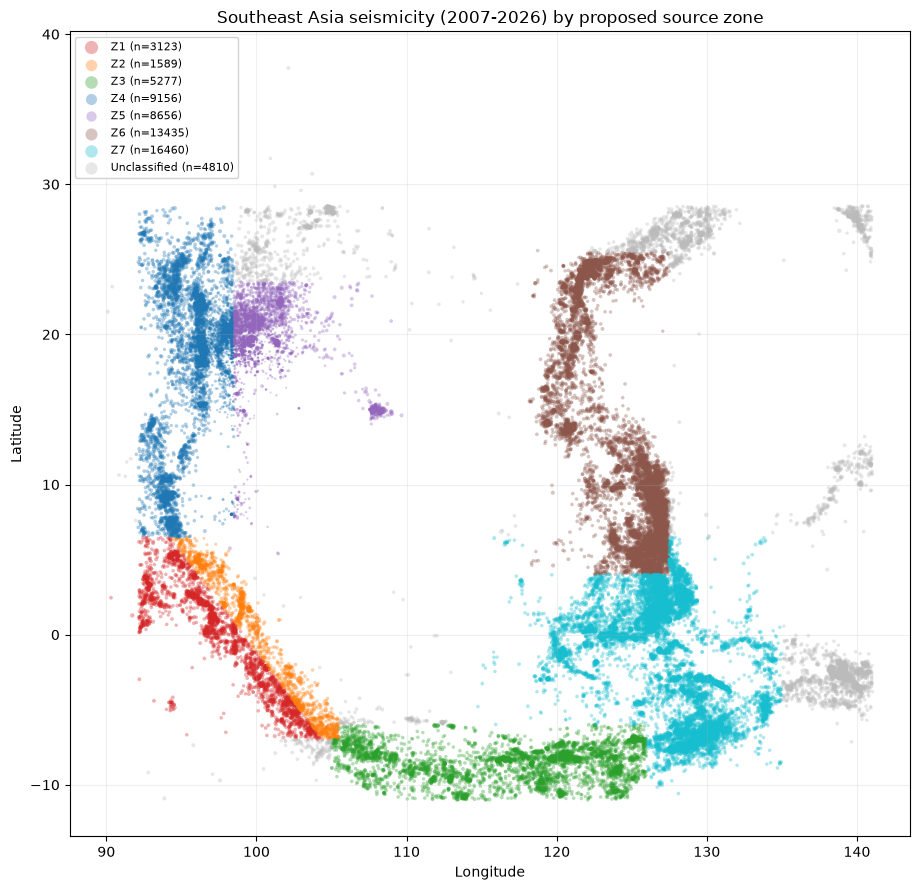

In [6]:
ZONE_ORDER = ["Z1", "Z2", "Z3", "Z4", "Z5", "Z6", "Z7", "Unclassified"]
ZONE_COLOR = {
    "Z1": "#d62728", "Z2": "#ff7f0e", "Z3": "#2ca02c", "Z4": "#1f77b4",
    "Z5": "#9467bd", "Z6": "#8c564b", "Z7": "#17becf", "Unclassified": "#bbbbbb",
}

fig, ax = plt.subplots(figsize=(11, 9))
for zone in ZONE_ORDER:
    sub = df[df["zone_code"] == zone]
    if len(sub) == 0:
        continue
    ax.scatter(sub["lon"], sub["lat"], s=np.clip((sub["mag"] - 1) * 2, 1, None),
               color=ZONE_COLOR[zone], alpha=0.35, linewidths=0, label=f"{zone} (n={len(sub)})")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Southeast Asia seismicity (2007-2026) by proposed source zone")
ax.set_aspect("equal")
ax.legend(markerscale=3, fontsize=8, loc="upper left", framealpha=0.9)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig("figures/01_event_map.png", dpi=150)
plt.show()


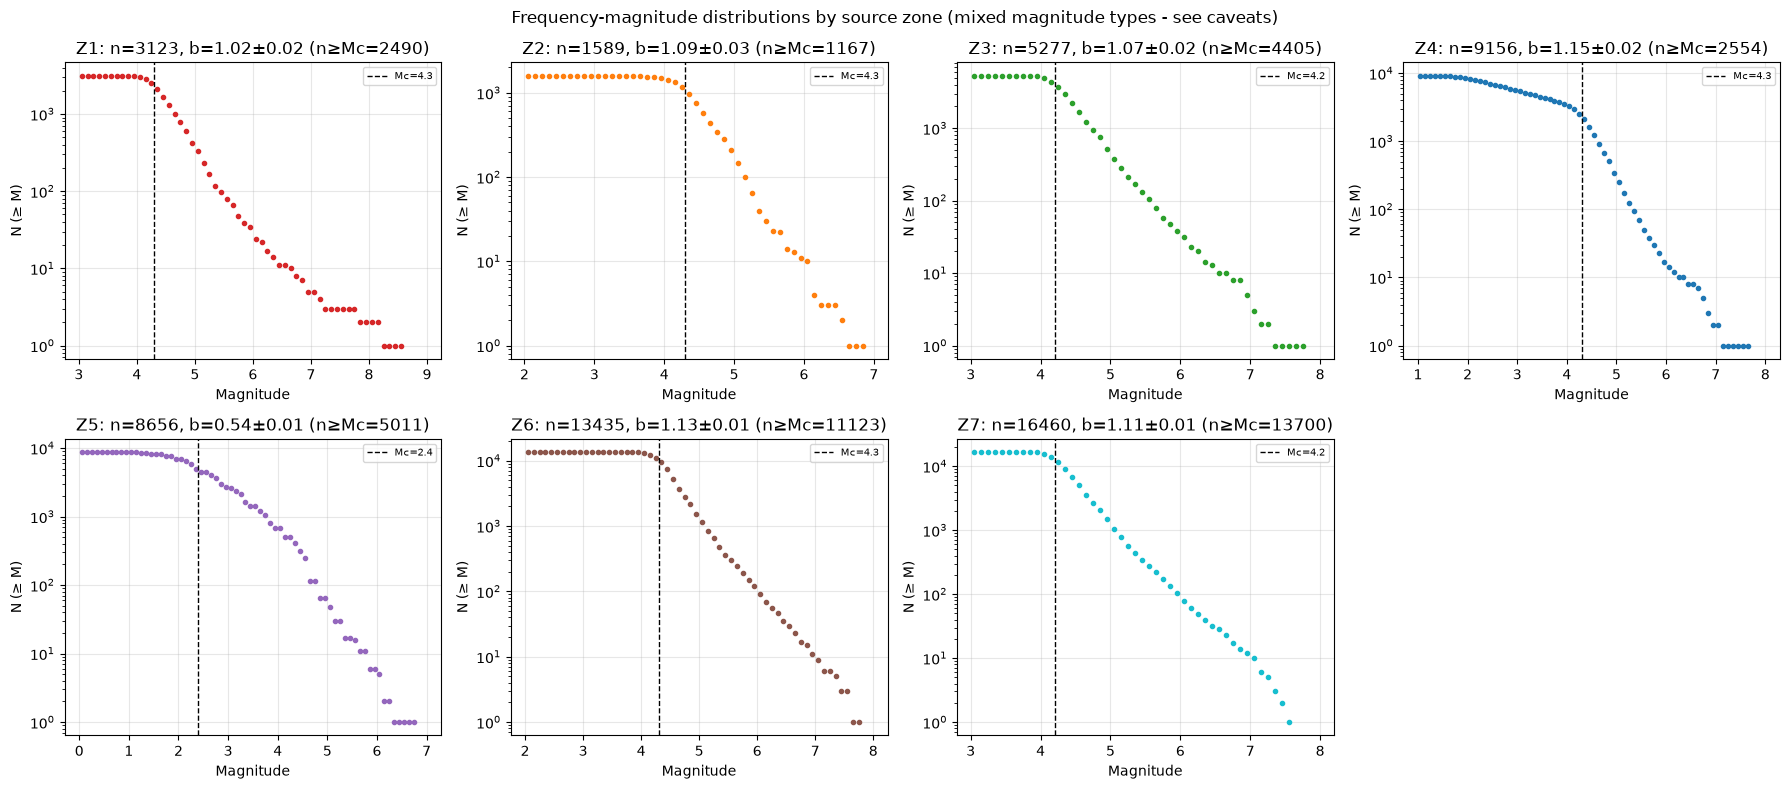

In [7]:
def max_curvature_mc(mags, dm=0.1):
    """Completeness magnitude via maximum curvature: the FMD's modal bin."""
    bins = np.arange(np.floor(mags.min() / dm) * dm, mags.max() + dm, dm)
    counts, edges = np.histogram(mags, bins=bins)
    if counts.sum() == 0:
        return np.nan
    return edges[np.argmax(counts)]


def aki_utsu_b_value(mags, mc, dm=0.1):
    """Maximum-likelihood b-value (Aki 1965 / Utsu 1965) for events >= mc."""
    m = mags[mags >= mc - dm / 2]
    n = len(m)
    if n < 30:
        return np.nan, np.nan, n
    mean_m = m.mean()
    b = np.log10(np.e) / (mean_m - (mc - dm / 2))
    return b, b / np.sqrt(n), n


zones = [z for z in ZONE_ORDER if z != "Unclassified"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
dm = 0.1
gr_rows = []
for i, zone in enumerate(zones):
    ax = axes[i]
    sub = df[df["zone_code"] == zone]
    mags = sub["mag"].dropna().values
    if len(mags) < 30:
        ax.set_title(f"{zone} (n={len(mags)}, too few events)")
        continue
    mc = max_curvature_mc(mags, dm)
    b, b_std, n_above = aki_utsu_b_value(mags, mc, dm)

    bins = np.arange(np.floor(mags.min()), np.ceil(mags.max()) + dm, dm)
    counts, edges = np.histogram(mags, bins=bins)
    centers = edges[:-1] + dm / 2
    cum = np.cumsum(counts[::-1])[::-1]

    ax.semilogy(centers, cum, "o", ms=3, color=ZONE_COLOR[zone])
    ax.axvline(mc, color="k", ls="--", lw=1, label=f"Mc={mc:.1f}")
    ax.set_title(f"{zone}: n={len(mags)}, b={b:.2f}\u00b1{b_std:.2f} (n\u2265Mc={n_above})")
    ax.set_xlabel("Magnitude"); ax.set_ylabel("N (\u2265 M)")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    gr_rows.append({"zone_code": zone, "mc": mc, "b_value": b, "b_value_std": b_std, "n_events_ge_mc": n_above})
for j in range(len(zones), len(axes)):
    axes[j].axis("off")
fig.suptitle("Frequency-magnitude distributions by source zone (mixed magnitude types - see caveats)")
fig.tight_layout()
fig.savefig("figures/02_magnitude_frequency.png", dpi=150)
plt.show()


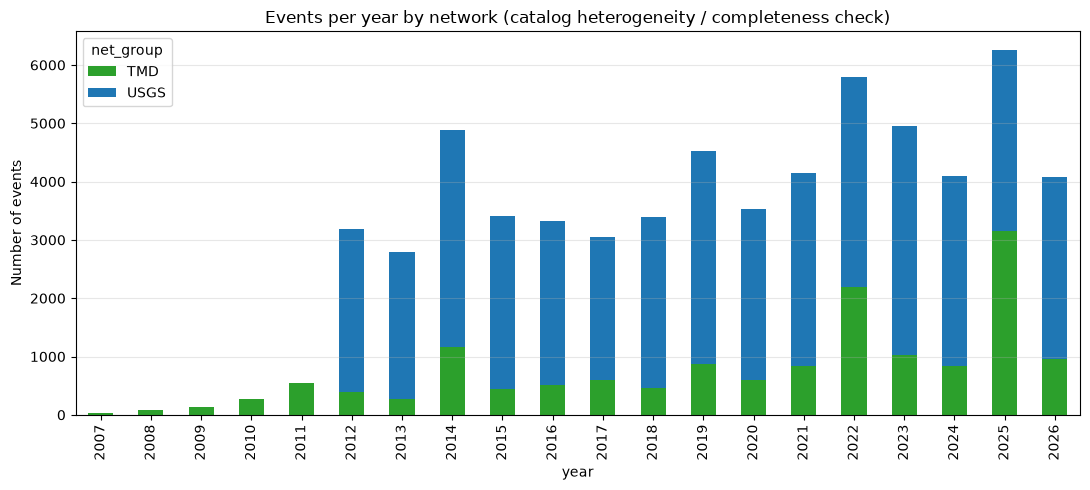

In [8]:
tmp = df.copy()
tmp["year"] = pd.to_datetime(tmp["time_utc"]).dt.year
tmp["net_group"] = tmp["network"].apply(lambda x: "TMD" if x == "TMD" else "USGS")
pivot = tmp.pivot_table(index="year", columns="net_group", values="event_id", aggfunc="count").fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(kind="bar", stacked=True, ax=ax, color={"TMD": "#2ca02c", "USGS": "#1f77b4"})
ax.set_ylabel("Number of events")
ax.set_title("Events per year by network (catalog heterogeneity / completeness check)")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("figures/03_temporal_distribution.png", dpi=150)
plt.show()


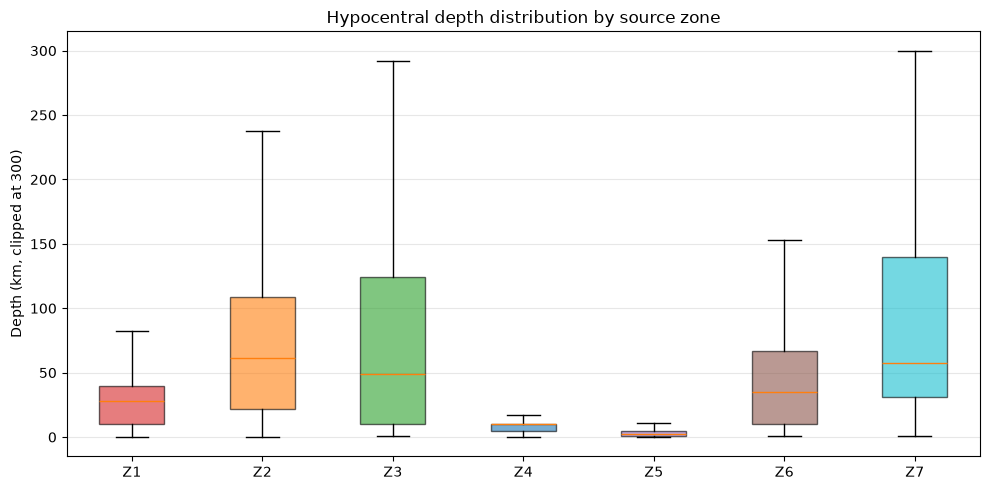

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
data = [df.loc[df["zone_code"] == z, "depth_km"].dropna().clip(upper=300) for z in zones]
bp = ax.boxplot(data, tick_labels=zones, showfliers=False, patch_artist=True)
for patch, zone in zip(bp["boxes"], zones):
    patch.set_facecolor(ZONE_COLOR[zone]); patch.set_alpha(0.6)
ax.set_ylabel("Depth (km, clipped at 300)")
ax.set_title("Hypocentral depth distribution by source zone")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("figures/04_depth_histogram.png", dpi=150)
plt.show()


In [10]:
rows = []
for zone in ZONE_ORDER:
    sub = df[df["zone_code"] == zone]
    if len(sub) == 0:
        continue
    rows.append({
        "zone_code": zone, "n_events": len(sub), "mag_min": sub["mag"].min(),
        "mag_max": sub["mag"].max(), "depth_median_km": sub["depth_km"].median(),
        "time_min": sub["time_utc"].min(), "time_max": sub["time_utc"].max(),
    })
summary = pd.DataFrame(rows).merge(pd.DataFrame(gr_rows), on="zone_code", how="left")
summary.to_csv("reports/zone_summary.csv", index=False)
summary


,zone_code,n_events,mag_min,mag_max,depth_median_km,time_min,time_max,mc,b_value,b_value_std,n_events_ge_mc
0,Z1,3123,3.40,8.6,28.070,2007-11-10 23:20:00.000,2026-09-05 09:14:15.563,4.3,1.024920,0.020540,2490.0
1,Z2,1589,2.70,6.9,61.530,2007-10-01 14:03:00.000,2026-09-09 00:23:19.728,4.3,1.093065,0.031997,1167.0
2,Z3,5277,3.40,7.8,49.180,2012-01-01 08:59:52.110,2026-09-08 21:42:22.442,4.2,1.070697,0.016132,4405.0
3,Z4,9156,1.00,7.7,10.000,2007-10-09 02:35:00.000,2026-09-10 02:00:16.000,4.3,1.147539,0.022707,2554.0
4,Z5,8656,0.60,6.7,2.000,2007-01-04 08:38:00.000,2026-09-10 01:23:18.000,2.4,0.539874,0.007627,5011.0
5,Z6,13435,2.60,7.8,35.000,2012-01-04 06:59:56.950,2026-09-09 07:07:03.319,4.3,1.125857,0.010675,11123.0
6,Z7,16460,3.40,7.6,57.745,2012-01-01 01:22:07.660,2026-09-11 00:53:48.954,4.2,1.110230,0.009485,13700.0
7,Unclassified,4810,2.77,7.8,20.065,2008-03-02 18:26:00.000,2026-09-02 00:04:55.294,NaN,NaN,NaN,NaN


## Next steps (not yet implemented)

1. **Mainshock-aftershock declustering** (Gardner-Knopoff / Reasenberg / ETAS-based).
2. **Spatial probability model**: Omori-Utsu spatial decay kernel, full ETAS
   spatial kernel, or a gridded logistic/ML model using distance, azimuth
   relative to the zone trend, mainshock depth, and zone ID as features.
3. Train/validate per zone (event counts and b-values differ a lot across zones).
4. Refine the 7 zone boundaries with an authoritative fault database before
   computing mainshock-aftershock distances in the final model.

See `reports/02_eda_report.md` for the full discussion, including the
Z5 b-value anomaly and other data-quality caveats.


---
# Appended: filling the mainshock-aftershock gap

Everything above (Steps 1-3) is unchanged. The thesis topic is *spatial
probability of aftershocks given an identified mainshock*, but Steps 1-3 only
describe the catalog overall - they never look at mainshock-aftershock
structure. The sections below add that evidence, plus data-quality checks
that affect how much to trust it, ahead of building a real declustering +
spatial probability model.

New figures continue the numbering from `figures/05_...` onward; new tables
go to `reports/` as new filenames. Nothing above this point is modified.


## Reconciled zone map - depth-colored, resolved classification (figure 05)

An earlier ad hoc plot colored events by depth and overlaid 7 rectangular
zone boundaries, but used different zone names/boundaries than `classify()`
above (e.g. "Sagaing Fault", "Red River Fault Zone"). This redraws that idea
using the *same* `classify()` boundaries and Z1-Z7 codes as the rest of this
notebook. Because `classify()`'s if/elif priority order means the raw
bounding boxes overlap (e.g. Z6/Z7), this shades the actual *resolved*
classification on a fine lat/lon grid instead of drawing the raw boxes, and
marks Unclassified events distinctly (red x).


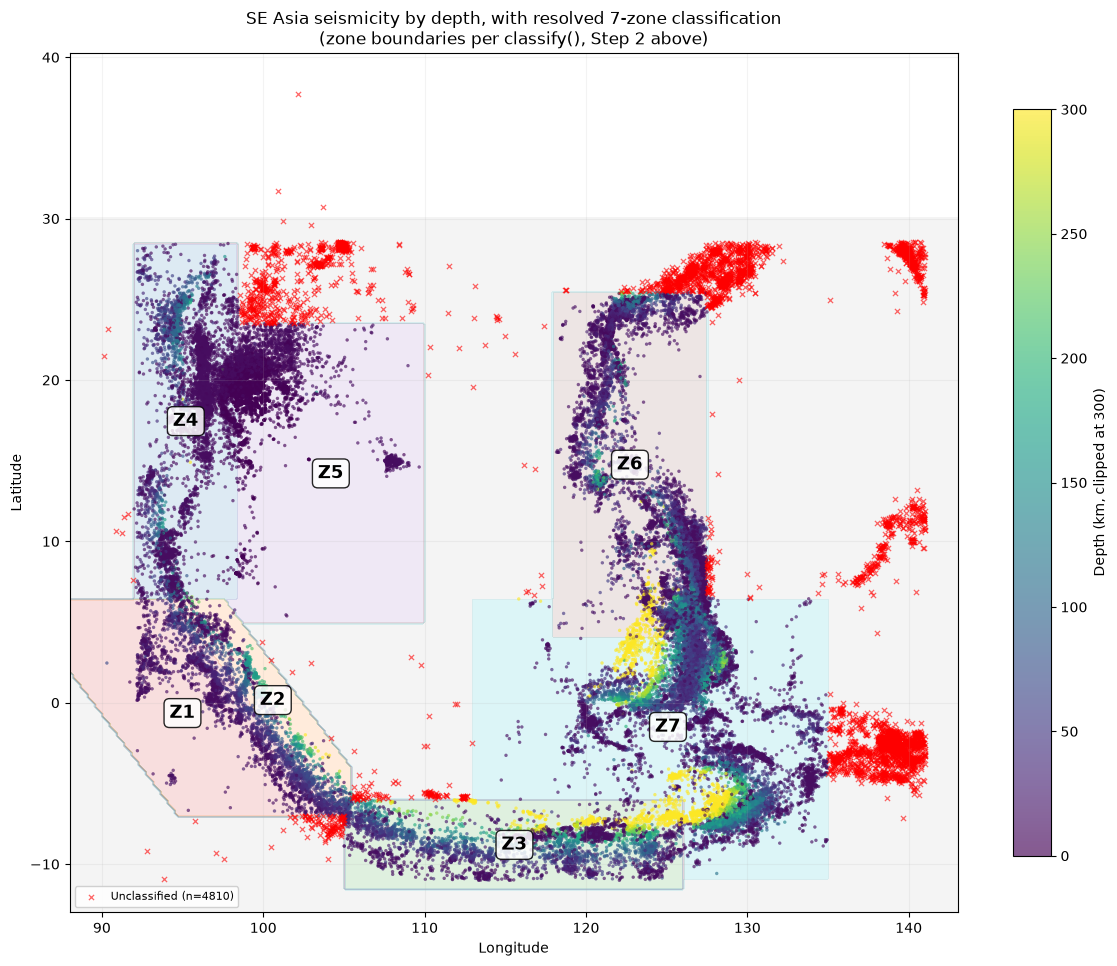

In [11]:
import matplotlib.colors as mcolors

def plot_depth_by_zone_viridis(df, grid_step=0.15):
    lon_grid = np.arange(88, 143 + grid_step, grid_step)
    lat_grid = np.arange(-13, 30 + grid_step, grid_step)
    LON, LAT = np.meshgrid(lon_grid, lat_grid)

    zone_codes = ZONE_ORDER  # ["Z1", ..., "Z7", "Unclassified"], from Step 3
    zone_to_int = {z: i for i, z in enumerate(zone_codes)}
    classify_vec = np.vectorize(lambda la, lo: zone_to_int[classify(la, lo)])
    ZGRID = classify_vec(LAT, LON)

    fig, ax = plt.subplots(figsize=(12, 10))
    bg_cmap = mcolors.ListedColormap([ZONE_COLOR[z] for z in zone_codes])
    bg_norm = mcolors.BoundaryNorm(np.arange(-0.5, len(zone_codes) + 0.5, 1), bg_cmap.N)
    ax.contourf(LON, LAT, ZGRID, levels=np.arange(-0.5, len(zone_codes) + 0.5, 1),
                cmap=bg_cmap, norm=bg_norm, alpha=0.15)

    for zone in zone_codes:
        if zone == "Unclassified":
            continue
        mask = ZGRID == zone_to_int[zone]
        if mask.any():
            ax.text(LON[mask].mean(), LAT[mask].mean(), zone, fontsize=13, fontweight="bold",
                    ha="center", va="center", bbox=dict(boxstyle="round", fc="white", ec="black", alpha=0.85))

    classified = df[df["zone_code"] != "Unclassified"]
    unclassified = df[df["zone_code"] == "Unclassified"]
    sc = ax.scatter(classified["lon"], classified["lat"], c=classified["depth_km"].clip(upper=300),
                     cmap="viridis", s=6, alpha=0.65, linewidths=0)
    ax.scatter(unclassified["lon"], unclassified["lat"], marker="x", color="red", s=14, alpha=0.6,
               linewidths=0.9, label=f"Unclassified (n={len(unclassified)})")
    cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label("Depth (km, clipped at 300)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title("SE Asia seismicity by depth, with resolved 7-zone classification\n"
                 "(zone boundaries per classify(), Step 2 above)")
    ax.set_aspect("equal")
    ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
    ax.grid(alpha=0.15)
    fig.tight_layout()
    fig.savefig("figures/05_depth_by_zone.png", dpi=150)
    plt.show()

plot_depth_by_zone_viridis(df)


## Step 4 - Aftershock clustering diagnostics

Reuses the per-zone b-values already computed in Step 3's `gr_rows` (not
recomputed here), plus a fresh top-level `haversine_km` (Step 1's version is
nested inside `dedupe()` and isn't reachable from here).

**(a) Nearest-neighbor distance analysis** (Baiesi & Gerstenberger, 2004;
Zaliapin & Ben-Zion, 2013): for each event, find the preceding event that
minimizes the rescaled space-time distance eta = T x R. A distinct low-T,
low-R population separate from the diffuse background indicates
mainshock-aftershock clustering.


In [12]:
from scipy.spatial import cKDTree

def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))

# --- tunable constants ---
MAINSHOCK_MIN_MAG = 5.5
AFTERSHOCK_RADIUS_KM = 100.0
FRACTAL_DIMENSION = 1.6
NN_CANDIDATE_K = 30
MIN_CANDIDATES_FOR_ZONE_MODEL = 5
TOP_N_OVERALL_MAINSHOCKS = 3
OMORI_MAX_DAYS = 365
OMORI_P_REFERENCE = 1.0

ZONES_CLASSIFIED = [z for z in ZONE_ORDER if z != "Unclassified"]
df_classified = df[df["zone_code"] != "Unclassified"].copy()

b_by_zone = {row["zone_code"]: row["b_value"] for row in gr_rows}
print("Reusing per-zone b-values computed in Step 3:")
for z in ZONES_CLASSIFIED:
    print(f"  {z}: b={b_by_zone.get(z, float('nan')):.3f}")


Reusing per-zone b-values computed in Step 3:
  Z1: b=1.025
  Z2: b=1.093
  Z3: b=1.071
  Z4: b=1.148
  Z5: b=0.540
  Z6: b=1.126
  Z7: b=1.110


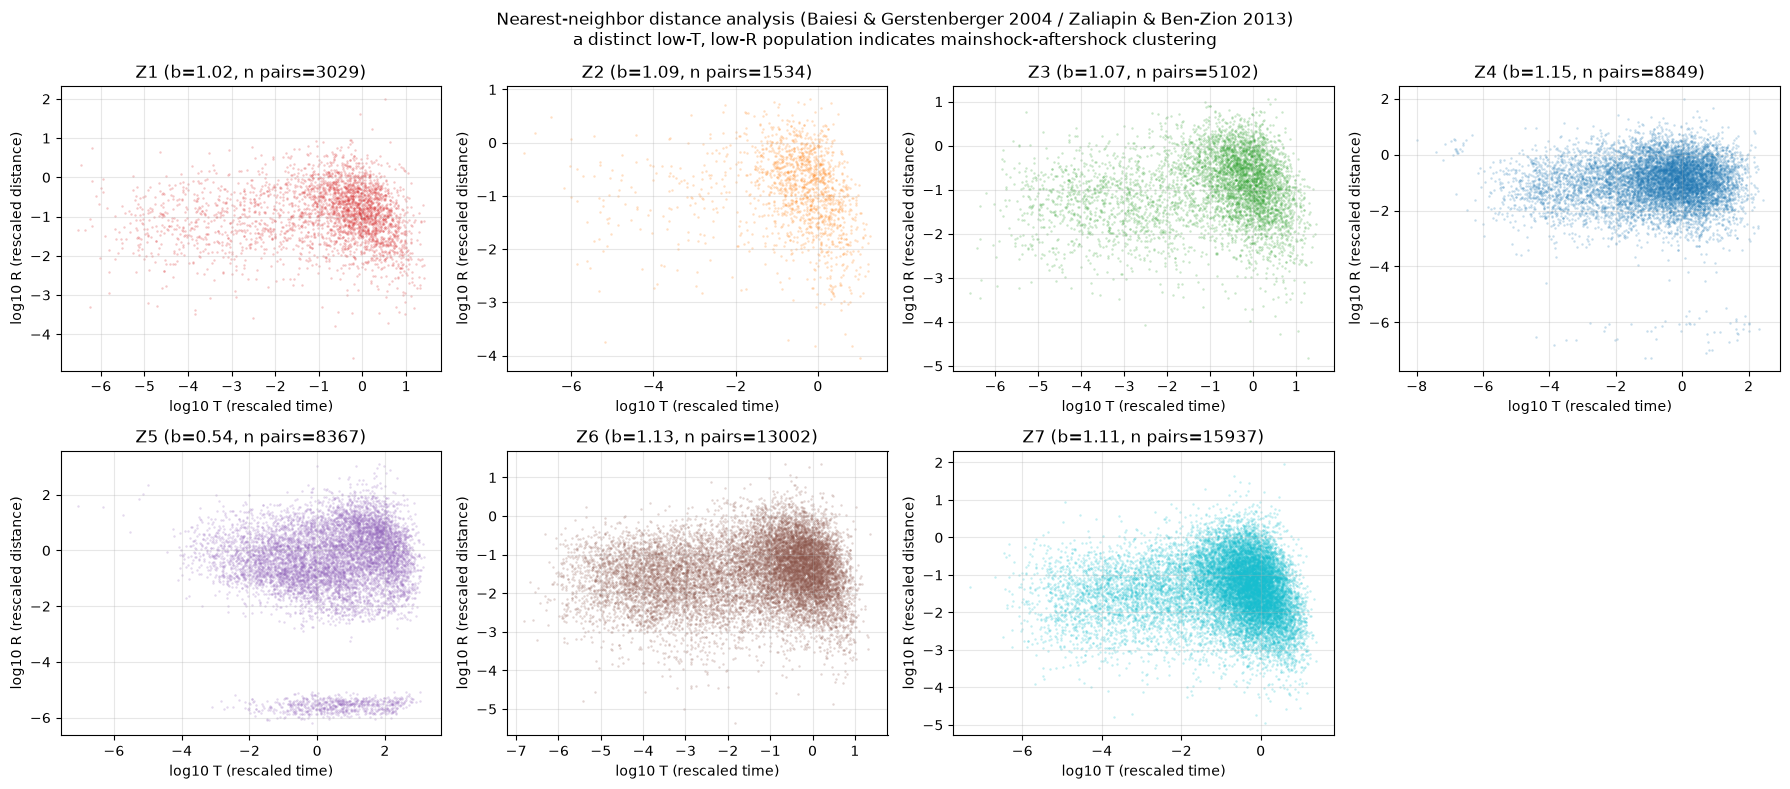

In [13]:
def nearest_neighbor_distances(df_zone, b_value, fractal_dim=FRACTAL_DIMENSION, k=NN_CANDIDATE_K):
    """Baiesi & Gerstenberger (2004) / Zaliapin & Ben-Zion (2013) nearest-
    neighbor distance: eta_ij = T_ij * R_ij, with
        T_ij = t_ij * 10^(-b*M_j/2), R_ij = r_ij^fractal_dim * 10^(-b*M_j/2).
    Only the k nearest spatial neighbors of each event are evaluated as
    parent candidates (eta is dominated by r_ij, so this rarely misses the
    true minimum, and keeps this tractable for 10k+ event zones)."""
    d = df_zone.sort_values("time_utc").reset_index(drop=True)
    n = len(d)
    if n < 10:
        return pd.DataFrame(columns=["T", "R", "eta", "parent_pos"])

    lat = d["lat"].to_numpy(); lon = d["lon"].to_numpy(); mags = d["mag"].to_numpy()
    t_days = (d["time_utc"].to_numpy() - d["time_utc"].to_numpy()[0]) / np.timedelta64(1, "D")

    tree = cKDTree(np.column_stack([lat, lon]))
    kk = min(k + 1, n)
    _, nbr_idx = tree.query(np.column_stack([lat, lon]), k=kk)

    T_out = np.full(n, np.nan); R_out = np.full(n, np.nan)
    eta_out = np.full(n, np.nan); parent_out = np.full(n, -1, dtype=int)

    for i in range(1, n):
        cands = nbr_idx[i]
        cands = cands[(cands != i) & (t_days[cands] < t_days[i])]
        if len(cands) == 0:
            continue
        r_km = np.maximum(haversine_km(lat[i], lon[i], lat[cands], lon[cands]), 1e-3)
        t_ij = t_days[i] - t_days[cands]
        scale = 10 ** (-b_value * mags[cands] / 2)
        T = t_ij * scale
        R = (r_km ** fractal_dim) * scale
        eta = T * R
        best = np.argmin(eta)
        T_out[i], R_out[i], eta_out[i], parent_out[i] = T[best], R[best], eta[best], cands[best]

    mask = ~np.isnan(eta_out)
    return pd.DataFrame({"T": T_out[mask], "R": R_out[mask], "eta": eta_out[mask], "parent_pos": parent_out[mask]})


zones_with_b = [z for z in ZONES_CLASSIFIED if not pd.isna(b_by_zone.get(z, np.nan))]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, zone in enumerate(zones_with_b):
    ax = axes[i]
    sub = df_classified[df_classified["zone_code"] == zone]
    b = b_by_zone[zone]
    nn = nearest_neighbor_distances(sub, b)
    if len(nn) < 10:
        ax.set_title(f"{zone} (n={len(nn)}, too few pairs)")
        continue
    logT = np.log10(nn["T"].clip(lower=1e-8))
    logR = np.log10(nn["R"].clip(lower=1e-8))
    ax.scatter(logT, logR, s=3, alpha=0.25, color=ZONE_COLOR[zone], linewidths=0)
    ax.set_title(f"{zone} (b={b:.2f}, n pairs={len(nn)})")
    ax.set_xlabel("log10 T (rescaled time)"); ax.set_ylabel("log10 R (rescaled distance)")
    ax.grid(alpha=0.3)
for j in range(len(zones_with_b), len(axes)):
    axes[j].axis("off")
fig.suptitle("Nearest-neighbor distance analysis (Baiesi & Gerstenberger 2004 / Zaliapin & Ben-Zion 2013)\n"
             "a distinct low-T, low-R population indicates mainshock-aftershock clustering")
fig.tight_layout()
fig.savefig("figures/06_nn_distance_clustering.png", dpi=150)
plt.show()


**(b) Inter-event time histograms**, log-y, overlaid with the fitted
exponential (Poisson null hypothesis) - an excess of short inter-event times
over the fit indicates overdispersion/clustering. (The reference curve is
computed in log-space and masked before it floating-point-underflows to
~0, which otherwise stretches a log-y axis across hundreds of decades and
hides the histogram.)


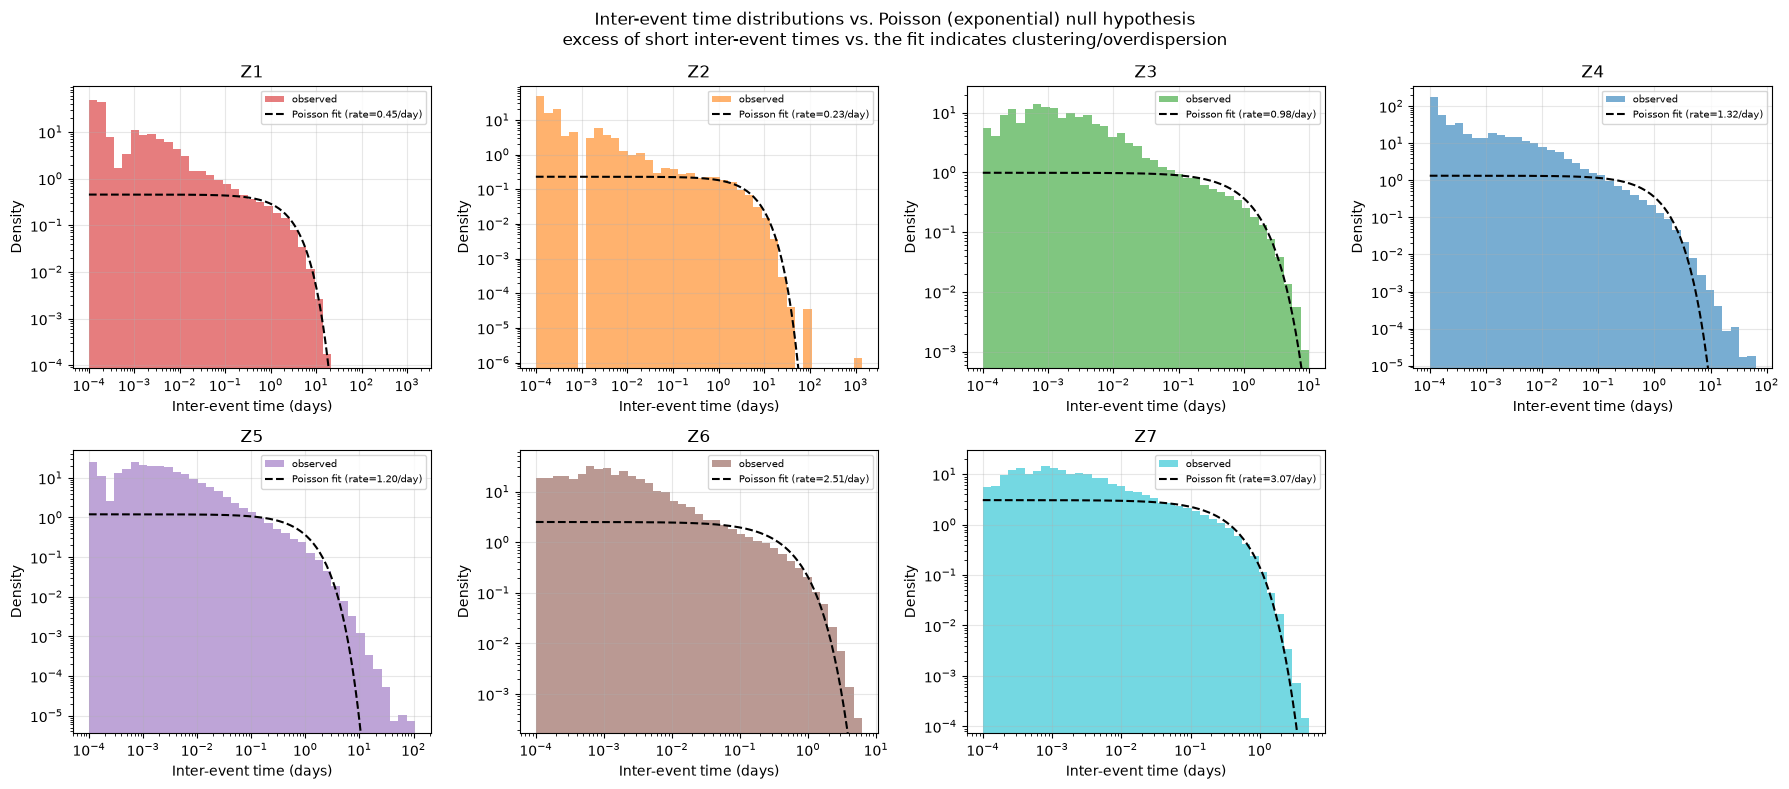

In [14]:
zones_enough = [z for z in ZONES_CLASSIFIED if (df_classified["zone_code"] == z).sum() >= 10]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, zone in enumerate(zones_enough):
    ax = axes[i]
    sub = df_classified[df_classified["zone_code"] == zone].sort_values("time_utc")
    t = sub["time_utc"].to_numpy()
    dt_days = np.diff(t) / np.timedelta64(1, "D")
    dt_days = dt_days[dt_days > 0]
    if len(dt_days) < 10:
        ax.set_title(f"{zone} (n={len(dt_days)}, too few)")
        continue
    rate = 1.0 / dt_days.mean()
    bins = np.logspace(np.log10(max(dt_days.min(), 1e-4)), np.log10(dt_days.max()), 40)
    counts, edges = np.histogram(dt_days, bins=bins, density=True)
    positive = counts[counts > 0]
    ax.stairs(counts, edges, fill=True, alpha=0.6, color=ZONE_COLOR[zone], label="observed")

    xs = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), 200)
    log10_model = np.log10(rate) - rate * xs / np.log(10)
    floor = np.log10(positive.min()) - 2 if len(positive) else -10
    model_mask = log10_model > floor
    ax.plot(xs[model_mask], 10 ** log10_model[model_mask], "k--", lw=1.5,
            label=f"Poisson fit (rate={rate:.2f}/day)")

    ax.set_xscale("log"); ax.set_yscale("log")
    if len(positive):
        top = max(positive.max(), 10 ** log10_model[model_mask].max() if model_mask.any() else positive.max())
        ax.set_ylim(bottom=positive.min() * 0.5, top=top * 2)
    ax.set_xlabel("Inter-event time (days)"); ax.set_ylabel("Density")
    ax.set_title(zone); ax.legend(fontsize=7); ax.grid(alpha=0.3)
for j in range(len(zones_enough), len(axes)):
    axes[j].axis("off")
fig.suptitle("Inter-event time distributions vs. Poisson (exponential) null hypothesis\n"
             "excess of short inter-event times vs. the fit indicates clustering/overdispersion")
fig.tight_layout()
fig.savefig("figures/07_interevent_time_histograms.png", dpi=150)
plt.show()


**(c) Candidate mainshock catalog**: all events with `mag >= MAINSHOCK_MIN_MAG`
(default 5.5), listed per zone and sorted by magnitude. Zones with fewer than
`MIN_CANDIDATES_FOR_ZONE_MODEL` (default 5) candidates are flagged - too
sparse to support their own per-zone aftershock model.


In [15]:
candidates = df_classified[df_classified["mag"] >= MAINSHOCK_MIN_MAG].copy()
candidates = candidates.sort_values(["zone_code", "mag"], ascending=[True, False])
cols = ["event_id", "zone_code", "zone_name", "time_utc", "lat", "lon", "depth_km", "mag", "mag_type", "network", "place"]
candidates = candidates[cols]
candidates.to_csv("reports/candidate_mainshocks.csv", index=False)

counts = candidates["zone_code"].value_counts()
print(f"Candidate mainshocks (mag >= {MAINSHOCK_MIN_MAG}): {len(candidates)} total")
print(counts.reindex(ZONES_CLASSIFIED, fill_value=0).to_string())
for zone in ZONES_CLASSIFIED:
    n = int(counts.get(zone, 0))
    if n < MIN_CANDIDATES_FOR_ZONE_MODEL:
        print(f"  WARNING: {zone} has only {n} candidate mainshock(s) (< {MIN_CANDIDATES_FOR_ZONE_MODEL}) "
              f"- too sparse to support a per-zone aftershock model.")
candidates.head()


Candidate mainshocks (mag >= 5.5): 1059 total
zone_code
Z1     98
Z2     30
Z3    132
Z4     70
Z5     16
Z6    366
Z7    347


,event_id,zone_code,zone_name,time_utc,lat,lon,depth_km,mag,mag_type,network,place
1844,USGS_official20120411083836720_20,Z1,Sunda Megathrust - Sumatra Segment,2012-04-11 08:38:36.720,2.3270,93.0630,20.0,8.6,mw,USGS/OFFICIAL,2012 Wharton Basin Earthquake
1857,USGS_usp000jhjb,Z1,Sunda Megathrust - Sumatra Segment,2012-04-11 10:43:10.850,0.8020,92.4630,25.1,8.2,mwc,USGS/US,2012 Wharton Basin Aftershock
15980,USGS_us10004u1y,Z1,Sunda Megathrust - Sumatra Segment,2016-03-02 12:49:48.110,-4.9521,94.3299,24.0,7.8,mww,USGS/US,"southwest of Sumatra, Indonesia"
1119,USGS_usp000jdar,Z1,Sunda Megathrust - Sumatra Segment,2012-01-10 18:36:59.080,2.4330,93.2100,19.0,7.2,mww,USGS/US,off the west coast of northern Sumatra
44604,USGS_us7000jvl3,Z1,Sunda Megathrust - Sumatra Segment,2023-04-24 20:00:57.265,-0.8082,98.5112,34.0,7.1,mww,USGS/US,"171 km SSE of Teluk Dalam, Indonesia"


**(d) Aftershock rate decay** for the 2-3 largest candidate mainshocks
overall, plus the largest in each zone with enough candidates, vs. days
since mainshock (log-log), with an Omori-Utsu p=1 reference line. The
aftershock search radius uses whichever is larger: a fixed
`AFTERSHOCK_RADIUS_KM` (100km), or 5x the Wells & Coppersmith (1994)
subsurface rupture length for that magnitude - so the window scales up for
very large mainshocks instead of staying fixed at 100km regardless of size.


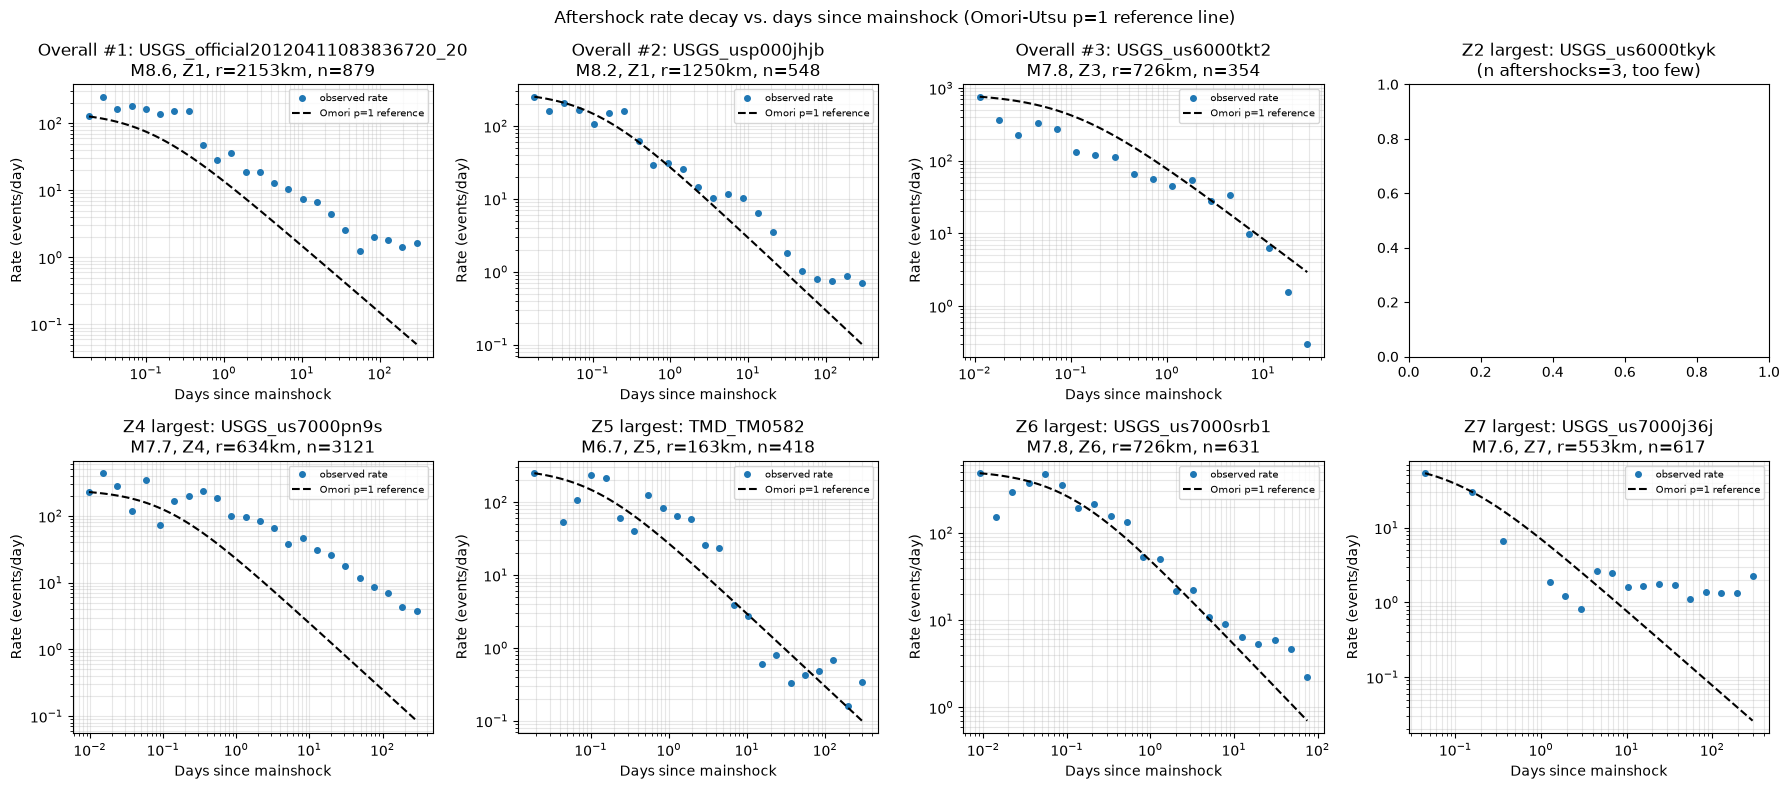

In [16]:
def wells_coppersmith_rupture_length_km(mag):
    """Subsurface rupture length (RLD), all-fault-type regression,
    Wells & Coppersmith (1994) Table 2A: log10(RLD [km]) = -2.44 + 0.59*M.
    A rough distance-scaling heuristic, not a precise rupture estimate."""
    return 10 ** (-2.44 + 0.59 * mag)

def aftershock_search_radius_km(mag, fixed_radius=AFTERSHOCK_RADIUS_KM):
    return max(fixed_radius, 5.0 * wells_coppersmith_rupture_length_km(mag))

def compute_aftershock_rate(df_src, mainshock, radius_km, max_days=OMORI_MAX_DAYS):
    t0 = mainshock["time_utc"]
    dt_days_all = (df_src["time_utc"] - t0).dt.total_seconds() / 86400.0
    dist_km = haversine_km(mainshock["lat"], mainshock["lon"], df_src["lat"].to_numpy(), df_src["lon"].to_numpy())
    mask = ((dt_days_all > 0) & (dt_days_all <= max_days) & (dist_km <= radius_km) &
            (df_src["event_id"] != mainshock["event_id"]))
    dts = dt_days_all[mask].to_numpy()
    if len(dts) < 5:
        return None, None, len(dts)
    bins = np.logspace(np.log10(max(dts.min(), 1e-3)), np.log10(max_days), 25)
    counts, edges = np.histogram(dts, bins=bins)
    widths = np.diff(edges)
    centers = np.sqrt(edges[:-1] * edges[1:])
    rate = counts / widths
    valid = counts > 0
    return centers[valid], rate[valid], len(dts)

# Select mainshocks: top overall + largest per zone (skipping zones already covered)
selections = []
overall_top = candidates.sort_values("mag", ascending=False).head(TOP_N_OVERALL_MAINSHOCKS)
for _, row in overall_top.iterrows():
    selections.append((f"Overall #{len(selections) + 1}", row))
already = {r["event_id"] for _, r in selections}
for zone in ZONES_CLASSIFIED:
    if counts.get(zone, 0) < MIN_CANDIDATES_FOR_ZONE_MODEL:
        continue
    top_row = candidates[candidates["zone_code"] == zone].sort_values("mag", ascending=False).iloc[0]
    if top_row["event_id"] in already:
        continue
    selections.append((f"{zone} largest", top_row))
    already.add(top_row["event_id"])

n = len(selections)
ncols = min(4, n)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), squeeze=False)
axes = axes.flatten()
for i, (label, row) in enumerate(selections):
    ax = axes[i]
    radius = aftershock_search_radius_km(row["mag"])
    centers, rate, n_aft = compute_aftershock_rate(df_classified, row, radius)
    if centers is None:
        ax.set_title(f"{label}: {row['event_id']}\n(n aftershocks={n_aft}, too few)")
        continue
    ax.loglog(centers, rate, "o", ms=4, color="#1f77b4", label="observed rate")
    c_offset = 0.1
    k_anchor = rate[0] * (centers[0] + c_offset)
    t_ref = np.logspace(np.log10(centers.min()), np.log10(centers.max()), 100)
    ax.loglog(t_ref, k_anchor / (t_ref + c_offset), "k--", lw=1.5, label=f"Omori p={OMORI_P_REFERENCE:.0f} reference")
    ax.set_xlabel("Days since mainshock"); ax.set_ylabel("Rate (events/day)")
    ax.set_title(f"{label}: {row['event_id']}\nM{row['mag']:.1f}, {row['zone_code']}, r={radius:.0f}km, n={n_aft}")
    ax.legend(fontsize=7); ax.grid(alpha=0.3, which="both")
for j in range(len(selections), len(axes)):
    axes[j].axis("off")
fig.suptitle("Aftershock rate decay vs. days since mainshock (Omori-Utsu p=1 reference line)")
fig.tight_layout()
fig.savefig("figures/08_omori_decay_curves.png", dpi=150)
plt.show()


## Step 5 - Data-quality diagnostics

**(a) Magnitude-type composition** by network and by zone - TMD reports ML,
USGS reports a mix of mb/mww/ml/... This matters because it affects
comparability of b-values and mainshock thresholds across zones/networks.


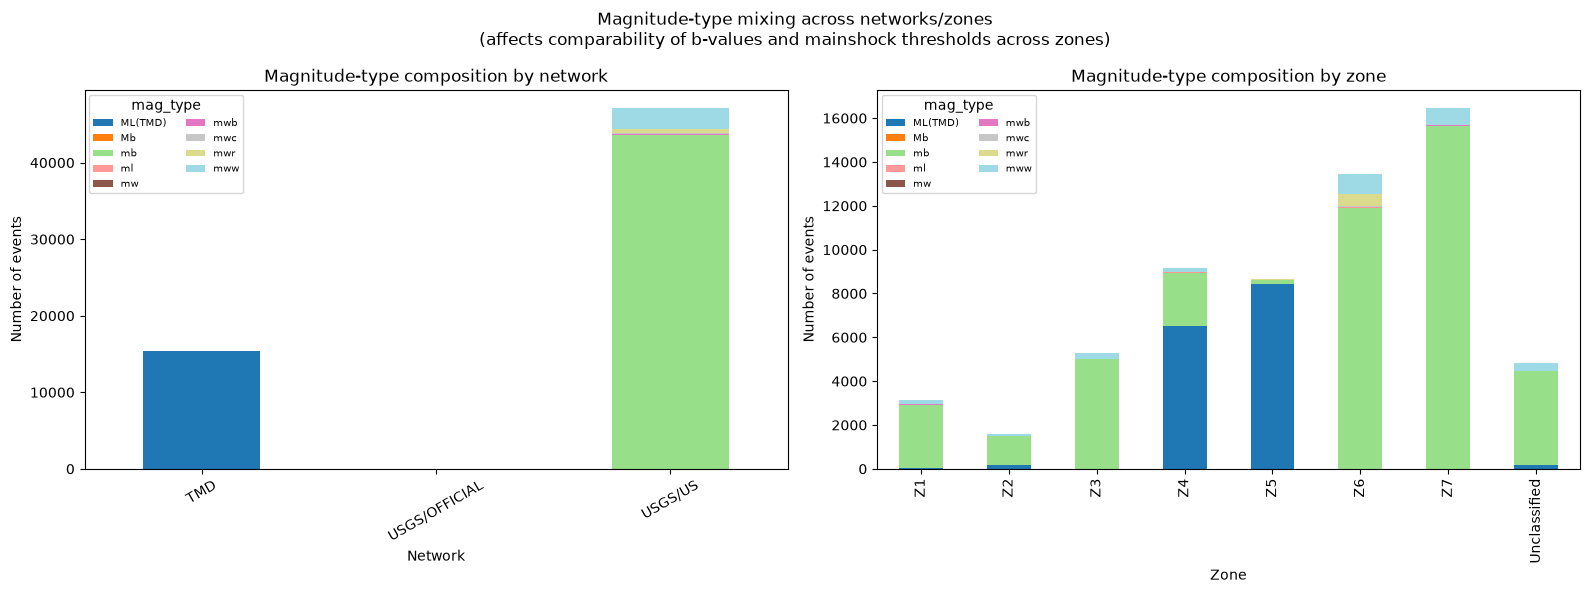

In [17]:
net_ct = df.groupby(["network", "mag_type"]).size().reset_index(name="count")
net_ct.insert(0, "group_type", "network")
net_ct = net_ct.rename(columns={"network": "group_value"})

zone_ct = df.groupby(["zone_code", "mag_type"]).size().reset_index(name="count")
zone_ct.insert(0, "group_type", "zone")
zone_ct = zone_ct.rename(columns={"zone_code": "group_value"})

pd.concat([net_ct, zone_ct], ignore_index=True).to_csv("reports/magtype_composition.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
net_pivot = net_ct.pivot(index="group_value", columns="mag_type", values="count").fillna(0)
net_pivot.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab20")
axes[0].set_title("Magnitude-type composition by network"); axes[0].set_xlabel("Network")
axes[0].set_ylabel("Number of events"); axes[0].legend(fontsize=7, ncol=2, title="mag_type")
axes[0].tick_params(axis="x", rotation=30)

zone_pivot = zone_ct.pivot(index="group_value", columns="mag_type", values="count").fillna(0)
zone_pivot = zone_pivot.loc[[z for z in ZONE_ORDER if z in zone_pivot.index]]
zone_pivot.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title("Magnitude-type composition by zone"); axes[1].set_xlabel("Zone")
axes[1].set_ylabel("Number of events"); axes[1].legend(fontsize=7, ncol=2, title="mag_type")

fig.suptitle("Magnitude-type mixing across networks/zones\n"
             "(affects comparability of b-values and mainshock thresholds across zones)")
fig.tight_layout()
fig.savefig("figures/09_magtype_composition.png", dpi=150)
plt.show()


**(b) Dedup offset diagnostics**: the actual (time, distance) offset of every
TMD-USGS matched pair found by Step 1's dedup logic, to check whether the
60s/50km cutoffs are well chosen. Reuses `tmd`/`usgs` from Step 1 and a fresh
`dedupe_with_diagnostics` (Step 1's `dedupe()` only returns the deduped
frame, not per-pair offsets - added here rather than changing it).


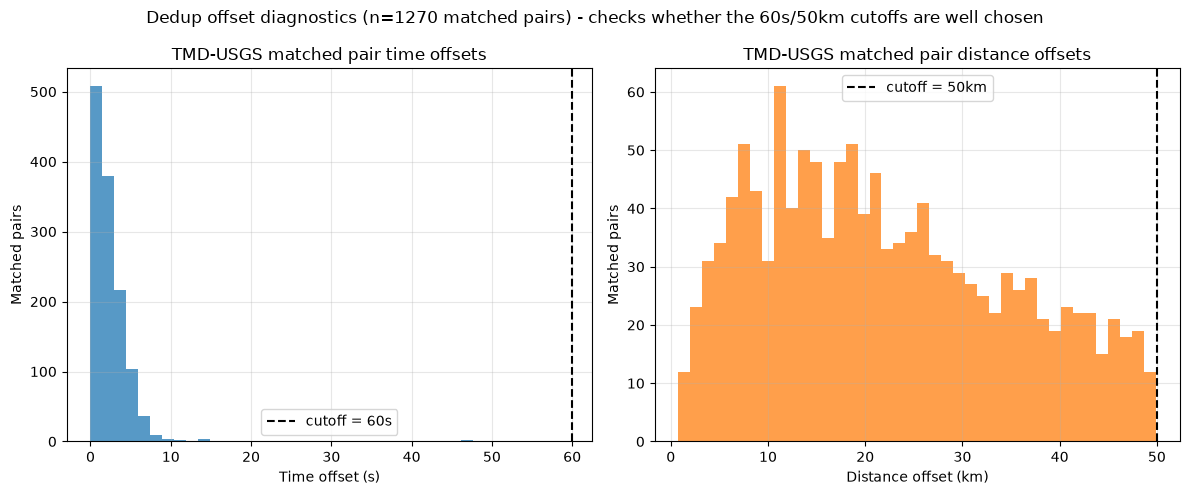

       time_offset_s  distance_km
count    1270.000000  1270.000000
mean        2.556034    22.163758
std         3.723354    12.683277
min         0.000000     0.792003
25%         0.893500    11.605931
50%         1.951000    20.364556
75%         3.308750    31.764948
max        59.490000    49.919856


In [18]:
def dedupe_with_diagnostics(tmd_df, usgs_df, time_window_s=60, dist_window_km=50):
    t = tmd_df.sort_values("time_utc").reset_index(drop=True)
    u = usgs_df.sort_values("time_utc").reset_index(drop=True)
    u_times = u["time_utc"].values; u_lat = u["lat"].values; u_lon = u["lon"].values

    window = np.timedelta64(time_window_s, "s")
    is_dup = np.zeros(len(t), dtype=bool)
    matches = []
    lo = 0
    for i, ti in enumerate(t["time_utc"].values):
        while lo < len(u_times) and u_times[lo] < ti - window:
            lo += 1
        best = None
        jj = lo
        while jj < len(u_times) and u_times[jj] <= ti + window:
            d = haversine_km(t["lat"].iloc[i], t["lon"].iloc[i], u_lat[jj], u_lon[jj])
            if d <= dist_window_km:
                dt_s = abs((u_times[jj] - ti) / np.timedelta64(1, "s"))
                if best is None or d < best[0]:
                    best = (d, dt_s)
            jj += 1
        if best is not None:
            is_dup[i] = True
            matches.append((i, best[1], best[0]))
    match_df = pd.DataFrame(matches, columns=["tmd_index", "time_offset_s", "distance_km"])
    return t.loc[~is_dup].reset_index(drop=True), match_df

_, match_df = dedupe_with_diagnostics(tmd, usgs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(match_df["time_offset_s"], bins=40, color="#1f77b4", alpha=0.75)
axes[0].axvline(60, color="k", ls="--", label="cutoff = 60s")
axes[0].set_xlabel("Time offset (s)"); axes[0].set_ylabel("Matched pairs")
axes[0].set_title("TMD-USGS matched pair time offsets"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(match_df["distance_km"], bins=40, color="#ff7f0e", alpha=0.75)
axes[1].axvline(50, color="k", ls="--", label="cutoff = 50km")
axes[1].set_xlabel("Distance offset (km)"); axes[1].set_ylabel("Matched pairs")
axes[1].set_title("TMD-USGS matched pair distance offsets"); axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle(f"Dedup offset diagnostics (n={len(match_df)} matched pairs) - checks whether the 60s/50km cutoffs are well chosen")
fig.tight_layout()
fig.savefig("figures/10_dedup_offset_diagnostics.png", dpi=150)
plt.show()

print(match_df[["time_offset_s", "distance_km"]].describe())


**(c) Missing-data audit**: rows dropped at each cleaning filter step, per
source. Mirrors `load_tmd()`/`load_usgs()` from Step 1 but records counts
per-step instead of only the combined before/after (those functions
themselves are not changed).


In [19]:
def load_tmd_with_audit():
    d = pd.read_csv(RAW_TMD, encoding="cp874")
    d.columns = [c.strip() for c in d.columns]
    steps = [("raw_rows", len(d))]
    out = pd.DataFrame()
    out["time_utc"] = pd.to_datetime(d["DATE-TIME UTC"], errors="coerce")
    out["lat"] = pd.to_numeric(d["LAT."], errors="coerce")
    out["lon"] = pd.to_numeric(d["LONG."], errors="coerce")
    out["mag"] = pd.to_numeric(d["MAG."], errors="coerce")
    n = len(out)
    out = out.dropna(subset=["time_utc"]); steps.append(("dropped_unparseable_time", n - len(out))); n = len(out)
    out = out.dropna(subset=["lat", "lon"]); steps.append(("dropped_unparseable_latlon", n - len(out))); n = len(out)
    out = out[(out["lat"].between(-90, 90)) & (out["lon"].between(-180, 180))]
    steps.append(("dropped_out_of_range_latlon", n - len(out))); n = len(out)
    out = out.dropna(subset=["mag"]); steps.append(("dropped_unparseable_mag", n - len(out))); n = len(out)
    out = out[out["mag"] > 0]; steps.append(("dropped_mag_le_0", n - len(out))); n = len(out)
    steps.append(("kept", n))
    return steps

def load_usgs_with_audit():
    d = pd.read_csv(RAW_USGS)
    steps = [("raw_rows", len(d))]
    d = d[d["type"] == "earthquake"]
    steps.append(("dropped_non_earthquake_type", steps[0][1] - len(d)))
    n = len(d)
    out = pd.DataFrame()
    out["time_utc"] = pd.to_datetime(d["time"], errors="coerce", utc=True).dt.tz_localize(None)
    out["lat"] = pd.to_numeric(d["latitude"], errors="coerce")
    out["lon"] = pd.to_numeric(d["longitude"], errors="coerce")
    out["mag"] = pd.to_numeric(d["mag"], errors="coerce")
    out = out.dropna(subset=["time_utc"]); steps.append(("dropped_unparseable_time", n - len(out))); n = len(out)
    out = out.dropna(subset=["lat", "lon"]); steps.append(("dropped_unparseable_latlon", n - len(out))); n = len(out)
    out = out[(out["lat"].between(-90, 90)) & (out["lon"].between(-180, 180))]
    steps.append(("dropped_out_of_range_latlon", n - len(out))); n = len(out)
    out = out.dropna(subset=["mag"]); steps.append(("dropped_unparseable_mag", n - len(out))); n = len(out)
    out = out[out["mag"] > 0]; steps.append(("dropped_mag_le_0", n - len(out))); n = len(out)
    steps.append(("kept", n))
    return steps

tmd_steps = load_tmd_with_audit()
usgs_steps = load_usgs_with_audit()
audit = pd.DataFrame(
    [{"source": "TMD", "step": s, "count": c} for s, c in tmd_steps] +
    [{"source": "USGS", "step": s, "count": c} for s, c in usgs_steps]
)
audit.to_csv("reports/missing_data_audit.csv", index=False)
audit


,source,step,count
0,TMD,raw_rows,16656
1,TMD,dropped_unparseable_time,0
2,TMD,dropped_unparseable_latlon,0
3,TMD,dropped_out_of_range_latlon,0
4,TMD,dropped_unparseable_mag,0
5,TMD,dropped_mag_le_0,0
6,TMD,kept,16656
7,USGS,raw_rows,47151
8,USGS,dropped_non_earthquake_type,0
9,USGS,dropped_unparseable_time,0


**(d) Unclassified-event audit**: how many events `classify()` couldn't
place, and where they are (by place name and lat/lon extent), to gauge
whether the 7-zone boundaries need revising.


In [20]:
unclass = df[df["zone_code"] == "Unclassified"]
frac = len(unclass) / len(df) * 100
print(f"Unclassified events: {len(unclass)} / {len(df)} ({frac:.1f}%)")

place_counts = unclass["place"].value_counts().head(30).reset_index()
place_counts.columns = ["place", "count"]
place_counts.to_csv("reports/unclassified_audit.csv", index=False)

print(f"\nUnclassified lat range: [{unclass['lat'].min():.2f}, {unclass['lat'].max():.2f}], "
      f"lon range: [{unclass['lon'].min():.2f}, {unclass['lon'].max():.2f}]")
place_counts.head(15)


Unclassified events: 4810 / 62506 (7.7%)

Unclassified lat range: [-10.90, 37.75], lon range: [90.10, 141.02]


,place,count
0,"Bonin Islands, Japan region",357
1,"มณฑลยูนนาน, ประเทศจีน",80
2,"Papua, Indonesia",58
3,"southwest of Sumatra, Indonesia",35
4,"Ryukyu Islands, Japan",28
5,ยูนนาน ประเทศจีน,28
6,"near the north coast of Papua, Indonesia",24
7,"Volcano Islands, Japan region",17
8,มณฑลยูนนาน ประเทศจีน,14
9,"State of Yap, Federated States of Micronesia",12


## Step 6 - Temporal completeness refinement

The Step 3 b-value analysis computes a single Mc per zone over the entire
2007-2026 span, but Step 3's temporal plot already shows TMD's event rate
changing a lot over time (network build-out). This checks whether Mc is
actually stationary, by recomputing it (reusing `max_curvature_mc` from Step
3, unmodified) in rolling time windows per zone. Windows near the end of the
catalog (2026+) are truncated to less than the full window length, since
there isn't 5 more years of data after them yet.


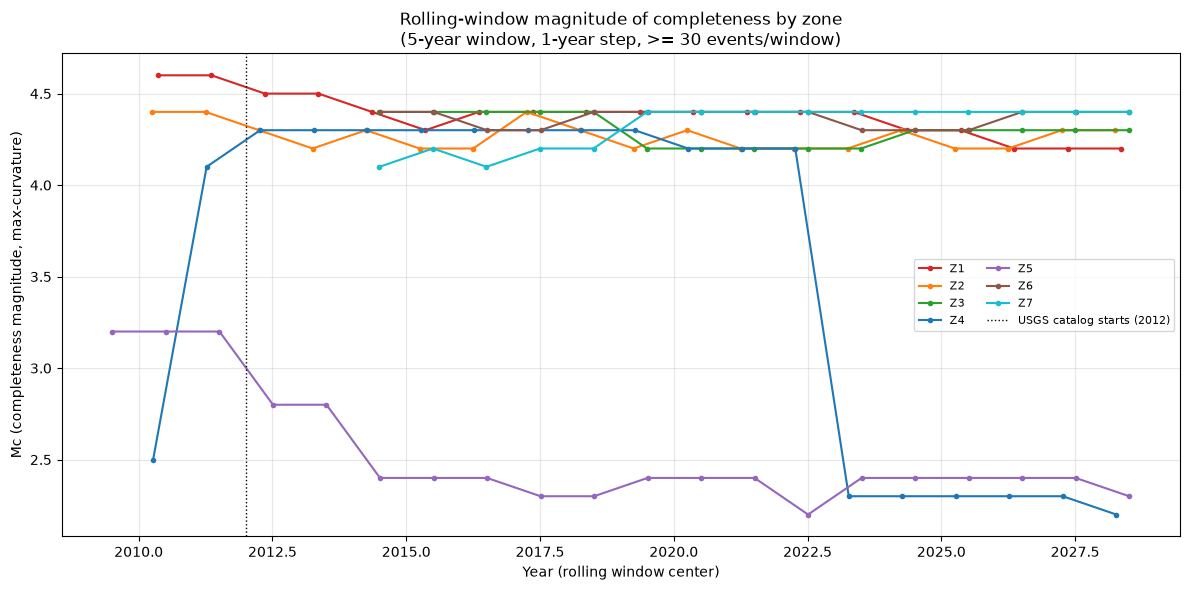

In [21]:
ROLLING_WINDOW_YEARS = 5
ROLLING_STEP_YEARS = 1
MIN_EVENTS_PER_WINDOW = 30

df_mc = df_classified.copy()
df_mc["year"] = df_mc["time_utc"].dt.year + (df_mc["time_utc"].dt.dayofyear - 1) / 365.25

results = []
for zone in ZONES_CLASSIFIED:
    sub = df_mc[df_mc["zone_code"] == zone]
    if len(sub) < MIN_EVENTS_PER_WINDOW:
        continue
    y_min, y_max = sub["year"].min(), sub["year"].max()
    start = y_min
    while start < y_max:
        end = start + ROLLING_WINDOW_YEARS
        window = sub[(sub["year"] >= start) & (sub["year"] < end)]
        if len(window) >= MIN_EVENTS_PER_WINDOW:
            mc = max_curvature_mc(window["mag"].dropna().values)
            results.append({"zone_code": zone, "window_start": round(start, 2), "window_end": round(end, 2),
                             "window_center": round((start + end) / 2, 2), "n_events": len(window), "mc": mc})
        start += ROLLING_STEP_YEARS

mc_df = pd.DataFrame(results)
mc_df.to_csv("reports/completeness_over_time.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 6))
for zone in ZONES_CLASSIFIED:
    sub = mc_df[mc_df["zone_code"] == zone]
    if len(sub) == 0:
        continue
    ax.plot(sub["window_center"], sub["mc"], marker="o", ms=3, color=ZONE_COLOR[zone], label=zone)
ax.axvline(2012, color="k", ls=":", lw=1, label="USGS catalog starts (2012)")
ax.set_xlabel("Year (rolling window center)"); ax.set_ylabel("Mc (completeness magnitude, max-curvature)")
ax.set_title(f"Rolling-window magnitude of completeness by zone\n"
             f"({ROLLING_WINDOW_YEARS}-year window, {ROLLING_STEP_YEARS}-year step, >= {MIN_EVENTS_PER_WINDOW} events/window)")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("figures/11_mc_over_time.png", dpi=150)
plt.show()


---
## Notes on this appended analysis

See the "New in this appendix" section at the end of `reports/02_eda_report.md`
for the write-up of what these figures/tables show (clustering evidence,
data-quality caveats, and what changes for the modeling stage).
